# Clase 1 · Enseñarle a una máquina con ejemplos

**Machine Learning** · Programa de Especialización Data Scientist · Sesión 1 de 16

Docente: **Josef Renato Rodriguez**

---

## Qué es esto del Machine Learning

Hasta hoy, cuando querías que un programa tomara una decisión, **tú escribías la regla**:

> «Si el cliente debe más de la mitad de lo que gana, márcalo como riesgoso.»

En Machine Learning se invierte el orden: le das al programa **miles de ejemplos ya resueltos**
(clientes que cayeron en mora y clientes que no) y el programa **encuentra la regla por su cuenta**.

| | Programación tradicional | Machine Learning |
|---|---|---|
| Tú le das | reglas + datos | datos + respuestas |
| Te devuelve | respuestas | **las reglas** (el modelo) |

## Qué vas a hacer hoy

| Bloque | Contenido | Min |
|---|---|---|
| 1 | Reglas escritas a mano vs reglas aprendidas | 12 |
| 2 | El vocabulario y los tipos de problema | 10 |
| 3 | Memorizar no es aprender: entrenamiento, validación y prueba | 20 |
| 4 | La API de scikit-learn: el mismo código para cualquier modelo | 10 |

## Cómo se usa este notebook

- Ejecuta cada celda con **Shift + Enter**, de arriba abajo, sin saltarte ninguna.
- Las celdas **`# ── TU CÓDIGO ──`** tienen `None` donde te toca escribir.
- Justo debajo hay una celda **`# ── VERIFICACIÓN ──`**: ejecútala y te dice `[OK]` o `[X ]`.
- Las celdas **`# ── DEMOSTRACIÓN ──`** ya vienen completas: solo ejecútalas y lee el resultado.

---
## Celda 0 · Preparación y datos

Los datos de hoy **se generan aquí mismo**: no hay nada que descargar. Son 2 000 clientes
simulados de una cartera de consumo, construidos para parecerse a los de verdad.
Usamos siempre la misma semilla (`SEED = 42`) para que tus números coincidan con los de la presentación.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings("ignore")

SEED = 42
NAVY, BLUE, MAG, GREEN, GRAY = "#0A2559", "#1A56E8", "#E6115E", "#12B886", "#5B6B87"
plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

def check(nombre, obtenido, esperado, tol=1e-3):
    if obtenido is None:
        print(f"[ ] {nombre}: todavía no calculaste nada")
        return False
    ok = abs(float(obtenido) - float(esperado)) <= tol
    print(f"{'[OK]' if ok else '[X ]'} {nombre}")
    print(f"     tu resultado: {float(obtenido):.4f}   |   esperado: {float(esperado):.4f}")
    return ok

def check_bool(nombre, cond, pista=""):
    print(f"{'[OK]' if cond else '[X ]'} {nombre}")
    if not cond and pista:
        print(f"     pista: {pista}")
    return bool(cond)

def generar_clientes(n=2000, seed=SEED):
    """Cartera simulada. La probabilidad de mora sube con la deuda y los atrasos,
    y baja con la antigüedad y el ingreso. El modelo NO conoce esta fórmula: la tiene que descubrir."""
    rng = np.random.default_rng(seed)
    ingreso = np.round(rng.lognormal(8.1, 0.45, n), -1)       # soles al mes
    ratio = np.round(rng.beta(2, 5, n) * 1.2, 3)              # deuda / ingreso
    antig = rng.integers(0, 21, n)                            # años como cliente
    atr = rng.poisson(0.8, n)                                 # atrasos en los últimos 12 meses
    z = -8 + 14*ratio + 2.0*atr - 0.15*antig - 0.5*(ingreso - 3300)/1000
    mora = rng.binomial(1, 1/(1 + np.exp(-z)))                # 1 = cayó en mora
    return pd.DataFrame({"ingreso": ingreso, "ratio_deuda": ratio, "antiguedad": antig,
                         "atrasos_12m": atr, "mora": mora})

clientes = generar_clientes()
FEATURES = ["ingreso", "ratio_deuda", "antiguedad", "atrasos_12m"]

print(f"{len(clientes)} clientes, {len(clientes.columns)} columnas\n")
print(clientes.head(6).to_string(index=False))

2000 clientes, 5 columnas

 ingreso  ratio_deuda  antiguedad  atrasos_12m  mora
  3780.0        0.202           2            0     0
  2060.0        0.200          18            0     0
  4620.0        0.091           5            1     0
  5030.0        0.429           8            2     1
  1370.0        0.513           9            0     0
  1830.0        0.507           7            0     0


### Las columnas

| Columna | Qué es | Papel |
|---|---|---|
| `ingreso` | ingreso mensual, en soles | variable de entrada |
| `ratio_deuda` | deuda total / ingreso. 0.40 = debe el 40 % de lo que gana | variable de entrada |
| `antiguedad` | años como cliente del banco | variable de entrada |
| `atrasos_12m` | cuántas veces pagó tarde en el último año | variable de entrada |
| `mora` | **1 si cayó en mora, 0 si no** | **lo que queremos predecir** |

---
# Bloque 1 · Reglas escritas a mano vs reglas aprendidas  ·  12 min

Vamos a comparar tres formas de decidir quién va a caer en mora:

1. **No pensar nada**: decir siempre «no cae». Parece tonto, pero es la vara contra la que se mide todo.
2. **Una regla escrita por una persona** con experiencia.
3. **Una regla que la máquina encuentra sola** mirando los datos.

### Ejercicio 1.1 — La regla trivial

Antes de construir cualquier modelo, hay que saber cuánto acierta alguien que **no hace nada**.
Si casi nadie cae en mora, decir siempre «no» ya acierta muchísimo.

- `tasa_mora`: la proporción de clientes con `mora == 1`. Pista: la media de una columna de 0 y 1 es justo esa proporción.
- `exactitud_trivial`: la proporción de aciertos de quien dice siempre «no» → `1 - tasa_mora`.

In [2]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
tasa_mora = None           # proporción de clientes que cayeron en mora
exactitud_trivial = None   # aciertos de quien siempre dice "no cae"

if tasa_mora is not None:
    print(f"Cayó en mora el {100*tasa_mora:.1f} % de los clientes")

In [3]:
# ── VERIFICACIÓN 1.1 ─────────────────────────────────────────────────────
r = [check("tasa de mora", tasa_mora, 0.1980),
     check("exactitud de la regla trivial", exactitud_trivial, 0.8020)]
print()
print("1.1 OK" if all(r) else "Revisa 1.1")

[ ] tasa de mora: todavía no calculaste nada
[ ] exactitud de la regla trivial: todavía no calculaste nada

Revisa 1.1


### Ejercicio 1.2 — Una regla escrita a mano

Un analista de riesgos con años de experiencia propone:

> **Si el cliente debe más del 50 % de su ingreso, o tuvo 3 o más atrasos en el año, va a caer en mora.**

Tiene todo el sentido. Tradúcela a código y mide cuánto acierta.

- `pred_regla`: una columna de 1 y 0 con la predicción de la regla.
  Pista: `(condición_1) | (condición_2)` da `True`/`False`; con `.astype(int)` lo conviertes a 1/0.
- `exactitud_regla`: proporción de clientes donde `pred_regla` coincide con `mora`.

In [4]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
pred_regla = None        # 1 si la regla dice "cae en mora", 0 si no
exactitud_regla = None   # proporción de aciertos

if exactitud_regla is not None:
    print(f"La regla acierta el {100*exactitud_regla:.1f} %")

In [5]:
# ── VERIFICACIÓN 1.2 ─────────────────────────────────────────────────────
r = [check("exactitud de la regla del analista", exactitud_regla, 0.8410),
     check_bool("la regla le gana a la trivial",
                exactitud_regla is not None and exactitud_regla > exactitud_trivial)]
print()
print("1.2 OK" if all(r) else "Revisa 1.2")

[ ] exactitud de la regla del analista: todavía no calculaste nada
[X ] la regla le gana a la trivial

Revisa 1.2


### Demostración 1.3 — La máquina escribe sus propias reglas

Ahora le damos los mismos datos a un **árbol de decisión** (lo veremos a fondo en la Clase 7).
Solo le decimos cuántas preguntas seguidas puede hacer (`max_depth=2`) y lo dejamos buscar
**qué variables mirar y en qué umbral cortar**.

In [6]:
# ── DEMOSTRACIÓN 1.3 ─────────────────────────────────────────────────────
X = clientes[FEATURES]
y = clientes["mora"]

arbol2 = DecisionTreeClassifier(max_depth=2, random_state=SEED)
arbol2.fit(X, y)                              # aquí es donde "aprende"
exactitud_arbol2 = arbol2.score(X, y)

print("Las reglas que encontró el árbol:\n")
print(export_text(arbol2, feature_names=FEATURES))
print(f"exactitud del árbol = {exactitud_arbol2:.4f}\n")

if exactitud_trivial is None or exactitud_regla is None:
    print("(Completa los ejercicios 1.1 y 1.2 para ver la comparación en gráfico.)")
else:
    nombres = ["Siempre 'no'", "Regla del analista", "Árbol (aprendido)"]
    valores = [exactitud_trivial, exactitud_regla, exactitud_arbol2]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(nombres, valores, color=[GRAY, BLUE, MAG])
    for i, v in enumerate(valores):
        ax.text(v + 0.003, i, f"{v:.3f}", va="center")
    ax.set_xlim(0.75, 0.9)
    ax.set_xlabel("exactitud")
    ax.set_title("Tres formas de decidir quién cae en mora")
    plt.tight_layout(); plt.show()

Las reglas que encontró el árbol:

|--- ratio_deuda <= 0.47
|   |--- atrasos_12m <= 1.50
|   |   |--- class: 0
|   |--- atrasos_12m >  1.50
|   |   |--- class: 0
|--- ratio_deuda >  0.47
|   |--- atrasos_12m <= 0.50
|   |   |--- class: 0
|   |--- atrasos_12m >  0.50
|   |   |--- class: 1

exactitud del árbol = 0.8700

(Completa los ejercicios 1.1 y 1.2 para ver la comparación en gráfico.)


**Lee las reglas del árbol.** Nadie le dijo que mirara `ratio_deuda` ni `atrasos_12m`: las eligió él.
Y en lugar de «más del 50 %» encontró que el corte útil está cerca de **0.47**, y que basta con
**un** atraso cuando la deuda ya es alta.

Eso es Machine Learning: **los datos eligen los umbrales, no la intuición.**

> ⚠️ Pero hemos hecho trampa. Medimos la exactitud del árbol **con los mismos clientes con los
> que aprendió**. Es como corregir un examen con las mismas preguntas que el alumno ya vio resueltas.
> En el Bloque 3 vamos a ver cuánto nos engaña eso.

---
# Bloque 2 · El vocabulario y los tipos de problema  ·  10 min

### El diccionario del curso

Estas letras van a aparecer en todas las clases. Mejor fijarlas hoy.

| Símbolo | Se lee | Qué es | En nuestros datos |
|---|---|---|---|
| $X$ | «equis mayúscula» | la **tabla de variables de entrada** (features) | las 4 columnas de `FEATURES` |
| $y$ | «ye» | la **variable objetivo** (target), lo que queremos predecir | la columna `mora` |
| $\hat{y}$ | «ye sombrero» | la **predicción** del modelo | lo que devuelve `.predict()` |
| $n$ | «ene» | número de **observaciones** (filas) | 2 000 clientes |
| $p$ | «pe» | número de **variables** (columnas de $X$) | 4 |
| $f(X)$ | «efe de equis» | el **modelo**: la función que convierte $X$ en $\hat{y}$ | el árbol de la demo 1.3 |

Y dos palabras que se confunden mucho:

- **Parámetro**: lo que el modelo **aprende solo** de los datos. En el árbol: los umbrales (0.47, 0.5…).
- **Hiperparámetro**: lo que **tú decides antes** de entrenar. En el árbol: `max_depth=2`.

### Ejercicio 2.1 — Separar $X$ de $y$

- `X`: la tabla con las columnas de `FEATURES`.
- `y`: la columna `mora`.
- `n_obs`, `n_vars`: filas y columnas de `X`. Pista: `X.shape` devuelve las dos a la vez.

In [7]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
X = None
y = None
n_obs, n_vars = None, None

if X is not None:
    print(f"X tiene {n_obs} filas y {n_vars} columnas")

In [8]:
# ── VERIFICACIÓN 2.1 ─────────────────────────────────────────────────────
r = [check("n (observaciones)", n_obs, 2000, tol=0),
     check("p (variables)", n_vars, 4, tol=0),
     check_bool("mora NO está dentro de X (sería hacer trampa)",
                X is not None and "mora" not in X.columns,
                "X solo debe tener las columnas de FEATURES")]
print()
print("2.1 OK" if all(r) else "Revisa 2.1")

[ ] n (observaciones): todavía no calculaste nada
[ ] p (variables): todavía no calculaste nada
[X ] mora NO está dentro de X (sería hacer trampa)
     pista: X solo debe tener las columnas de FEATURES

Revisa 2.1


### Ejercicio 2.2 — ¿Qué tipo de problema es?

En este curso vas a ver tres tipos de problema, uno por módulo:

| Tipo | Qué predice | ¿Hay respuesta conocida en los datos? | Módulo |
|---|---|---|---|
| **Regresión** | un **número** (soles, días, %) | sí | 1 |
| **Clasificación** | una **etiqueta** (sí/no, A/B/C) | sí | 2 |
| **Clustering** | **grupos** que nadie definió antes | **no** | 3 |

Regresión y clasificación son **aprendizaje supervisado** (hay un $y$ del que aprender).
Clustering es **no supervisado** (no hay $y$: el modelo busca estructura por su cuenta).

Completa cada situación con `"regresion"`, `"clasificacion"` o `"clustering"` (sin tildes).

In [9]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
respuestas = {
    "a) Cuántos soles gastará un cliente con su tarjeta el próximo mes": None,
    "b) Si una transacción con tarjeta es fraude o no": None,
    "c) Separar a los clientes en segmentos parecidos, sin etiquetas previas": None,
    "d) Qué porcentaje de la deuda se perderá si el cliente no paga (LGD)": None,
    "e) Si un cliente caerá en mora en los próximos 12 meses": None,
    "f) Agrupar cajeros automáticos según su patrón de retiros": None,
}

In [10]:
# ── VERIFICACIÓN 2.2 ─────────────────────────────────────────────────────
correctas = ["regresion", "clasificacion", "clustering", "regresion", "clasificacion", "clustering"]
r = []
for (situacion, tu_resp), ok in zip(respuestas.items(), correctas):
    r.append(check_bool(situacion[:55] + "…", tu_resp == ok,
                        "¿predice un número, una etiqueta, o busca grupos sin etiqueta?"))
print()
print("Bloque 2 COMPLETO" if all(r) else f"Revisa 2.2: {sum(r)} de 6 correctas")

[X ] a) Cuántos soles gastará un cliente con su tarjeta el p…
     pista: ¿predice un número, una etiqueta, o busca grupos sin etiqueta?
[X ] b) Si una transacción con tarjeta es fraude o no…
     pista: ¿predice un número, una etiqueta, o busca grupos sin etiqueta?
[X ] c) Separar a los clientes en segmentos parecidos, sin e…
     pista: ¿predice un número, una etiqueta, o busca grupos sin etiqueta?
[X ] d) Qué porcentaje de la deuda se perderá si el cliente …
     pista: ¿predice un número, una etiqueta, o busca grupos sin etiqueta?
[X ] e) Si un cliente caerá en mora en los próximos 12 meses…
     pista: ¿predice un número, una etiqueta, o busca grupos sin etiqueta?
[X ] f) Agrupar cajeros automáticos según su patrón de retir…
     pista: ¿predice un número, una etiqueta, o busca grupos sin etiqueta?

Revisa 2.2: 0 de 6 correctas


---
# Bloque 3 · Memorizar no es aprender  ·  20 min

Un modelo no se construye para acertar con los datos que ya tienes: esos ya sabes cómo terminaron.
Se construye para acertar con **clientes que todavía no han llegado**. A eso se le llama **generalizar**.

### Demostración 3.1 — Tres alumnos preparando el mismo examen

Tenemos 20 puntos que siguen una curva, con algo de ruido. Ajustamos tres polinomios:

- **Grado 1** (una recta): el alumno que no estudió. Demasiado simple.
- **Grado 3**: el alumno que entendió la idea.
- **Grado 15**: el alumno que **memorizó las respuestas**, incluido el ruido.

Luego los evaluamos con **500 puntos nuevos** que no vieron nunca.

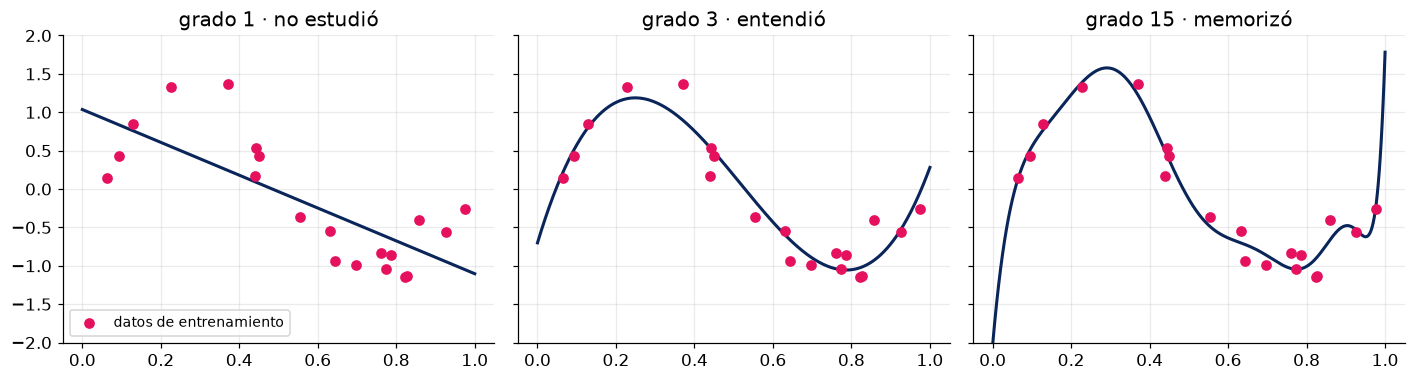

grado |  error ENTRENAMIENTO |  error datos NUEVOS
----------------------------------------------------
    1 |                0.512 |               0.531
    2 |                0.512 |               0.531
    3 |                0.220 |               0.342
    4 |                0.188 |               0.410
    5 |                0.181 |               0.374
    6 |                0.177 |               0.364
    7 |                0.176 |               0.364
    8 |                0.172 |               0.406
    9 |                0.173 |               0.382
   10 |                0.174 |               0.372
   11 |                0.175 |               0.368
   12 |                0.161 |               0.534
   13 |                0.161 |               0.500
   14 |                0.160 |               0.478
   15 |                0.160 |               0.466


In [11]:
# ── DEMOSTRACIÓN 3.1 ─────────────────────────────────────────────────────
rng_p = np.random.default_rng(SEED)
x_ent = rng_p.uniform(0, 1, 20)
y_ent = np.sin(2*np.pi*x_ent) + rng_p.normal(0, 0.3, 20)      # 20 puntos para aprender
x_nue = rng_p.uniform(0, 1, 500)
y_nue = np.sin(2*np.pi*x_nue) + rng_p.normal(0, 0.3, 500)     # 500 puntos nunca vistos

def rmse(real, pred):
    return np.sqrt(np.mean((real - pred) ** 2))

x_graf = np.linspace(0, 1, 400)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, g, titulo in zip(axes, [1, 3, 15], ["grado 1 · no estudió", "grado 3 · entendió", "grado 15 · memorizó"]):
    m = make_pipeline(PolynomialFeatures(g), LinearRegression()).fit(x_ent.reshape(-1, 1), y_ent)
    ax.scatter(x_ent, y_ent, color=MAG, zorder=3, label="datos de entrenamiento")
    ax.plot(x_graf, m.predict(x_graf.reshape(-1, 1)), color=NAVY, lw=2)
    ax.set_ylim(-2, 2); ax.set_title(titulo)
axes[0].legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'grado':>5} | {'error ENTRENAMIENTO':>20} | {'error datos NUEVOS':>19}")
print("-" * 52)
errores = []
for g in range(1, 16):
    m = make_pipeline(PolynomialFeatures(g), LinearRegression()).fit(x_ent.reshape(-1, 1), y_ent)
    e_ent = rmse(y_ent, m.predict(x_ent.reshape(-1, 1)))
    e_nue = rmse(y_nue, m.predict(x_nue.reshape(-1, 1)))
    errores.append((g, e_ent, e_nue))
    print(f"{g:>5} | {e_ent:>20.3f} | {e_nue:>19.3f}")

**Lo que muestra la tabla:**

- El error de **entrenamiento** baja siempre: de 0.512 con grado 1 a 0.080 con grado 15.
  Más complejidad = mejor memoria.
- El error con datos **nuevos** baja hasta grado 3 (0.342) y luego **se dispara**:
  con grado 15 llega a **547**.

| | Error entrenamiento | Error datos nuevos | Diagnóstico |
|---|---|---|---|
| Grado 1 | alto | alto | **underfitting** · subajuste |
| Grado 3 | bajo | bajo | **generaliza** |
| Grado 15 | casi cero | enorme | **overfitting** · sobreajuste |

> La señal de alarma del overfitting es siempre la misma: **una distancia grande entre el error de
> entrenamiento y el de datos nuevos.**

### Ejercicio 3.2 — Separar entrenamiento y prueba

La única forma de saber si un modelo generaliza es **esconderle una parte de los datos** mientras
aprende, y usarla solo al final para medir. Usa `train_test_split` con:

- `test_size=0.3` → 30 % para prueba.
- `random_state=SEED` → para que el corte sea siempre el mismo.
- `stratify=y` → para que la tasa de mora sea igual en las dos partes.

In [12]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = None, None, None, None   # train_test_split(X, y, ...)

if X_train is not None:
    print(f"entrenamiento: {len(X_train)} · prueba: {len(X_test)}")

In [13]:
# ── VERIFICACIÓN 3.2 ─────────────────────────────────────────────────────
r = [check("tamaño de entrenamiento", None if X_train is None else len(X_train), 1400, tol=0),
     check("tamaño de prueba", None if X_test is None else len(X_test), 600, tol=0),
     check("tasa de mora en prueba", None if y_test is None else y_test.mean(), 0.1983)]
print()
print("3.2 OK" if all(r) else "Revisa 3.2")

[ ] tamaño de entrenamiento: todavía no calculaste nada
[ ] tamaño de prueba: todavía no calculaste nada
[ ] tasa de mora en prueba: todavía no calculaste nada

Revisa 3.2


### Ejercicio 3.3 — Destapando la trampa del Bloque 1

Entrena un árbol **sin límite de profundidad** (`DecisionTreeClassifier(random_state=SEED)`) solo con
el entrenamiento, y mide su exactitud en las dos partes con `.score(X, y)`.

- `exac_train`: exactitud con `X_train`, `y_train` (los datos que vio).
- `exac_test`: exactitud con `X_test`, `y_test` (los que no vio).

In [14]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
arbol_libre = None   # crea el árbol sin max_depth y entrénalo con .fit(X_train, y_train)
exac_train = None
exac_test = None

if exac_test is not None:
    print(f"entrenamiento: {exac_train:.4f} · prueba: {exac_test:.4f}")

In [15]:
# ── VERIFICACIÓN 3.3 ─────────────────────────────────────────────────────
r = [check("exactitud en entrenamiento", exac_train, 1.0000),
     check("exactitud en prueba", exac_test, 0.8600),
     check_bool("hay una brecha grande entre entrenamiento y prueba",
                exac_train is not None and exac_train - exac_test > 0.1)]
print()
print("3.3 OK" if all(r) else "Revisa 3.3")

[ ] exactitud en entrenamiento: todavía no calculaste nada
[ ] exactitud en prueba: todavía no calculaste nada
[X ] hay una brecha grande entre entrenamiento y prueba

Revisa 3.3


### Ejercicio 3.4 — Elegir la profundidad sin tocar la prueba

¿Cuántos niveles le dejamos crecer al árbol? Es un **hiperparámetro**, así que lo decidimos nosotros.
La tentación es probar varias profundidades y quedarnos con la que mejor sale en prueba.
**Eso también es trampa**: estaríamos usando la prueba para elegir, y dejaría de ser «datos nunca vistos».

La solución es partir en **tres**:

| Parte | % | Analogía | Para qué |
|---|---|---|---|
| Entrenamiento | 60 | las prácticas | el modelo aprende |
| Validación | 20 | el simulacro | **tú** eliges hiperparámetros |
| Prueba | 20 | el examen final | se mira **una sola vez**, al final |

El corte ya está hecho abajo. Completa el bucle: para cada profundidad de 1 a 12, entrena con
`X_ent` y guarda la exactitud en entrenamiento y en **validación**.

In [16]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
X_tmp, X_prueba, y_tmp, y_prueba = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_ent, X_val, y_ent, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=SEED, stratify=y_tmp)
# 0.25 del 80 % restante = 20 % del total

profundidades = list(range(1, 13))
exac_ent_lista = []
exac_val_lista = []
for d in profundidades:
    modelo = None                      # árbol con max_depth=d y random_state=SEED, entrenado con X_ent
    exac_ent_lista.append(None)        # su exactitud en (X_ent, y_ent)
    exac_val_lista.append(None)        # su exactitud en (X_val, y_val)

mejor_prof = None          # la profundidad con MAYOR exactitud de validación
exac_final_prueba = None   # entrena con esa profundidad y mide UNA vez en (X_prueba, y_prueba)

TypeError: Expected sequence or array-like, got <class 'NoneType'>

In [ ]:
# ── VERIFICACIÓN 3.4 ─────────────────────────────────────────────────────
ok_lista = None not in exac_val_lista
r = [check_bool("guardaste las 12 exactitudes de validación", ok_lista,
                "dentro del bucle: modelo.score(X_val, y_val)"),
     check("profundidad elegida", mejor_prof, 5, tol=0),
     check("exactitud de validación con esa profundidad",
           max(exac_val_lista) if ok_lista else None, 0.8800),
     check("exactitud final en prueba", exac_final_prueba, 0.8875)]
print()
print("Bloque 3 COMPLETO" if all(r) else "Revisa 3.4")

In [ ]:
# ── DEMOSTRACIÓN 3.5 · la curva que vas a ver en todo el curso ───────────
if None not in exac_val_lista:
    fig, ax = plt.subplots()
    ax.plot(profundidades, exac_ent_lista, "o-", color=NAVY, label="entrenamiento")
    ax.plot(profundidades, exac_val_lista, "o-", color=MAG, label="validación")
    ax.axvline(mejor_prof, color=GRAY, ls="--", lw=1)
    ax.text(mejor_prof + 0.2, min(exac_val_lista), f"prof. {mejor_prof}", color=GRAY)
    ax.set_xlabel("profundidad del árbol (complejidad →)")
    ax.set_ylabel("exactitud")
    ax.set_title("Entrenamiento sube siempre; validación sube y luego baja")
    ax.legend(); plt.tight_layout(); plt.show()

A la izquierda de la línea, el árbol es demasiado simple (**underfitting**). A la derecha,
empieza a memorizar (**overfitting**): el entrenamiento sigue subiendo hasta 0.998,
pero la validación cae. Esta misma forma de curva la vas a ver con **todos** los modelos del curso,
cambiando lo que va en el eje horizontal.

---
# Bloque 4 · La API de scikit-learn  ·  10 min

La gran ventaja de scikit-learn es que **todos los modelos se usan igual**. Si aprendes estos
cuatro métodos, sabes usar los ~30 modelos que veremos en el curso:

| Método | Qué hace | Cuándo |
|---|---|---|
| `modelo.fit(X, y)` | aprende de los datos | con el entrenamiento |
| `modelo.predict(X)` | devuelve $\hat{y}$, la etiqueta o el número | con datos nuevos |
| `modelo.predict_proba(X)` | devuelve la **probabilidad** de cada clase | solo en clasificación |
| `modelo.score(X, y)` | mide qué tan bien le fue | con validación o prueba |

### Demostración 4.1 — Tres modelos, el mismo código

In [ ]:
# ── DEMOSTRACIÓN 4.1 ─────────────────────────────────────────────────────
modelos = {
    "árbol (prof. 5)": DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "regresión logística": LogisticRegression(max_iter=1000),
    "KNN (k = 15)": KNeighborsClassifier(n_neighbors=15),
}

print(f"Regla trivial en prueba: {1 - y_test.mean():.4f}\n")
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)                    # ← la misma línea para los tres
    exac = modelo.score(X_test, y_test)             # ← y esta también
    print(f"{nombre:<22} exactitud en prueba = {exac:.4f}")

Dos cosas para llevarse:

1. **La regresión logística gana** (0.920). No siempre gana el modelo más
   «sofisticado»: aquí los datos siguen una relación suave, y la logística encaja justo con eso (Clase 5).
2. **KNN empata con no hacer nada** (0.802). No es que KNN sea malo: mide distancias,
   y el `ingreso` (miles de soles) aplasta al `ratio_deuda` (entre 0 y 1). Se arregla **escalando**
   las variables, y lo veremos en la Clase 6. Primera lección de preprocesamiento: **las escalas importan**.

### Ejercicio 4.2 — Predecir un cliente nuevo

Llega una solicitud: ingreso de **S/ 2 800**, debe el **55 %** de lo que gana, **2 años** de cliente y
**2 atrasos** en el año. Con la regresión logística ya entrenada (`modelos["regresión logística"]`):

- `prob_mora`: la probabilidad de mora. Pista: `predict_proba` devuelve dos columnas, `[P(no), P(sí)]`;
  quieres la segunda de la primera fila → `[0, 1]`.
- `decision`: la etiqueta que da `.predict()` (0 o 1).

In [ ]:
# ── TU CÓDIGO ────────────────────────────────────────────────────────────
nuevo = pd.DataFrame([{"ingreso": 2800, "ratio_deuda": 0.55, "antiguedad": 2, "atrasos_12m": 2}])
logistica = modelos["regresión logística"]

prob_mora = None
decision = None

if prob_mora is not None:
    print(f"probabilidad de mora = {prob_mora:.1%} · decisión = {decision}")

In [ ]:
# ── VERIFICACIÓN 4.2 ─────────────────────────────────────────────────────
r = [check("probabilidad de mora del cliente nuevo", prob_mora, 0.9172, tol=2e-3),
     check("decisión (0 o 1)", decision, 1, tol=0)]
print()
print("Bloque 4 COMPLETO" if all(r) else "Revisa 4.2")

---
# Cierre

### Si te llevas una sola cosa

> **Un modelo vale por cómo le va con datos que nunca vio.** Todo lo demás del curso
> (métricas, validación cruzada, regularización, ensembles) son formas de medir y mejorar eso.

### Checklist de salida

- [ ] Sé explicar la diferencia entre programar reglas y aprenderlas de los datos.
- [ ] Sé qué son $X$, $y$, $\hat{y}$, parámetro e hiperparámetro.
- [ ] Distingo regresión, clasificación y clustering.
- [ ] Siempre comparo contra la **regla trivial** antes de celebrar.
- [ ] Sé separar entrenamiento, validación y prueba, y para qué sirve cada uno.
- [ ] Reconozco el overfitting: brecha grande entre entrenamiento y datos nuevos.
- [ ] Sé usar `fit`, `predict`, `predict_proba` y `score`.

### Los números del día

| | |
|---|---|
| Tasa de mora | 19.8 % |
| Exactitud de no hacer nada | 0.802 |
| Regla del analista | 0.841 |
| Árbol sin límite: entrenamiento → prueba | **1.000 → 0.860** |
| Polinomio grado 15: error de entrenamiento → datos nuevos | **0.080 → 547** |
| Profundidad elegida por validación | 5 (prueba: 0.887) |
| Mejor modelo en prueba | regresión logística, **0.920** |

### Próxima clase · Miércoles 30/9

**Clase 2 · Métricas de regresión y regresión lineal.** Hoy medimos todo con exactitud porque
predecíamos sí/no. Cuando lo que se predice es un número (soles, días), hace falta otra vara:
MAE, RMSE, R². Y empezamos con el modelo más importante de todos: la recta.